In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from catboost import CatBoostRegressor
from xgboost import XGBRegressor 
import builtins
_orig_setattr = None

In [60]:
cat_cols = ['pickup', 'delivery', 'equipment']
num_cols = ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "distance", "weight", "market_index", "quote_signal"]
date_cols = ['dow', 'month', 'day_of_year', 'year']
num_cols = num_cols + date_cols

In [61]:
target_col = 'posted_rate'

In [62]:
path = "~/SpotterTask/data/train-test.csv"

In [63]:
df = pd.read_csv(path)
df['weight'] = df['weight'].abs()

obj_cols = df.select_dtypes(include=['object']).columns
obj_cols = [col for col in obj_cols if col not in cat_cols]
df[obj_cols] = df[obj_cols].astype('string')
df['date'] = pd.to_datetime(df['date'])
df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['year'] = df['date'].dt.year 


In [64]:
df.drop(columns=['date'], inplace=True)

In [65]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate,dow,month,day_of_year,year
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.0
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31417.249245,1.083387,2.062468,2373.980682,3.003146,5.505312,151.828812,2025.0
std,4.315285,13.482431,4.317199,13.476589,728.564416,7996.515399,0.168091,0.291391,1486.493245,1.990637,2.864084,87.542630,0.0
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,5000.000000,0.676390,0.692280,57.220000,0.000000,1.000000,1.000000,2025.0
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25922.000000,0.949670,1.891030,1251.555000,1.000000,3.000000,77.000000,2025.0
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31496.000000,1.055800,2.055750,2030.760000,3.000000,5.000000,151.000000,2025.0
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37063.250000,1.219590,2.221685,3330.750000,5.000000,8.000000,227.000000,2025.0
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000,6.000000,10.000000,304.000000,2025.0


In [66]:
feature_cols = cat_cols + num_cols

In [67]:
X = df[feature_cols]
y = df[target_col]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
y_train_log = np.log1p(y_train)

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

In [106]:

for col in cat_cols:
    X_train_xgb[col] = X_train_xgb[col].astype('category')
    
train_categories = {col: X_train_xgb[col].cat.categories for col in cat_cols}
for col in cat_cols:
    X_test_xgb[col] = X_test_xgb[col].astype(
        pd.CategoricalDtype(categories=train_categories[col])
        )

In [107]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
    n_jobs=1
)
xgb_model.fit(X_train_xgb, y_train_log)
preds_xgb_log = xgb_model.predict(X_test_xgb)
preds_xgb = np.expm1(preds_xgb_log)

In [108]:
from catboost import Pool

In [73]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()
for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

train_pool = Pool(X_train_cb, y_train_log, cat_features=cat_cols)
test_pool = Pool(X_test_cb, np.log1p(y_test), cat_features=cat_cols)


In [74]:
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100
)

cb_model.fit(train_pool)
preds_cb_log = cb_model.predict(test_pool)
preds_cb = np.expm1(preds_cb_log)

0:	learn: 0.6380642	total: 73.8ms	remaining: 1m 13s
100:	learn: 0.1565192	total: 1.03s	remaining: 9.13s
200:	learn: 0.1542953	total: 1.92s	remaining: 7.64s
300:	learn: 0.1531545	total: 2.74s	remaining: 6.37s
400:	learn: 0.1523343	total: 3.51s	remaining: 5.25s
500:	learn: 0.1514787	total: 4.39s	remaining: 4.37s
600:	learn: 0.1505825	total: 5.26s	remaining: 3.5s
700:	learn: 0.1497404	total: 6.05s	remaining: 2.58s
800:	learn: 0.1488837	total: 6.89s	remaining: 1.71s
900:	learn: 0.1480184	total: 7.73s	remaining: 849ms
999:	learn: 0.1473256	total: 8.57s	remaining: 0us


In [75]:
def evaluate_model(model: str, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{model:10s} — MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | "
          f"R2: {r2:.4f} | MAPE: {mape:.2f}%")
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}


In [76]:
#Evaluation
results_xgb = evaluate_model("XGBoost", y_test, preds_xgb)
results_cb = evaluate_model("CatBoost", y_test, preds_cb)

XGBoost    — MAE:   126.02 | RMSE: 292157.53 | R2: 0.8634 | MAPE: 5.87%
CatBoost   — MAE:    89.54 | RMSE: 277726.76 | R2: 0.8701 | MAPE: 4.22%


In [77]:
val_path = "~/SpotterTask/data/validation.csv"

In [78]:
val_df = pd.read_csv(val_path)

In [79]:
val_df['weight'] = val_df['weight'].abs()

obj_cols = val_df.select_dtypes(include=['object']).columns
obj_cols = [col for col in obj_cols if col not in cat_cols]
val_df[obj_cols] = val_df[obj_cols].astype('string')
val_df['date'] = pd.to_datetime(val_df['date'])
val_df['dow'] = val_df['date'].dt.dayofweek
val_df['month'] = val_df['date'].dt.month
val_df['day_of_year'] = val_df['date'].dt.dayofyear
val_df['year'] = val_df['date'].dt.year 

In [80]:
import sys

In [81]:
missing_cols = [c for c in feature_cols if c not in val_df.columns]
if missing_cols:
    sys.exit(f"Error: Missing columns in validation data: {missing_cols}")
    

In [82]:
X_val = val_df[feature_cols].copy()


In [89]:
X_val.dtypes

pickup           object
delivery         object
equipment        object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
weight          float64
market_index    float64
quote_signal    float64
dow               int64
month             int64
day_of_year       int64
year              int64
dtype: object

In [83]:
X_val_xgb = X_val.copy()
X_val_cb = X_val.copy()

In [ ]:
# for col in cat_cols:
#     categories = X_train_xgb[col].astype("category").cat.categories

#     X_val_xgb[col] = pd.Series(
#         pd.Categorical(
#             X_val_xgb[col],
#             categories=categories
#         ),
#         index=X_val_xgb.index
#     )

In [109]:
for col in cat_cols:
    X_val_xgb[col] = X_val_xgb[col].astype(
        pd.CategoricalDtype(categories=train_categories[col])
    )

for col in cat_cols:
    X_val_cb[col] = X_val_cb[col].astype(str)

In [92]:
# X_val_xgb[col] = X_val_xgb[col].astype(
#         pd.CategoricalDtype(
#             categories=X_train_xgb[col].cat.categories
#         )
#     )

In [110]:
print(X_val_xgb[cat_cols].dtypes)

pickup       category
delivery     category
equipment    category
dtype: object


In [98]:
# for col in cat_cols:
#     X_val_cb[col] = X_val_cb[col].astype(str)
# val_pool = Pool(X_val_cb, cat_features=cat_cols)

In [99]:
# print(X_val_cb[cat_cols].dtypes)

In [111]:
val_pool = Pool(
    X_val_cb,
    cat_features=cat_cols
)

In [112]:
preds_val_xgb = np.expm1(xgb_model.predict(X_val_xgb))
preds_val_cb = np.expm1(cb_model.predict(val_pool))

In [113]:
preds_val_cb

array([ 856.24697963, 5180.53819383, 5304.56505245, ...,  915.37405697,
       3470.78629835,  569.40985126])

In [114]:
preds_val_xgb

array([ 836.3026 , 5283.4614 , 5335.371  , ...,  840.69995, 3330.8035 ,
        565.1959 ], dtype=float32)

In [119]:
unseen_cities = (
        set(X_val["pickup"].unique()) - set(train_categories["pickup"])
    ) | (
        set(X_val["delivery"].unique()) - set(train_categories["delivery"])
    )
val_df["low_confidence"] = (
    val_df["pickup"].isin(unseen_cities) | val_df["delivery"].isin(unseen_cities)
)

In [120]:
val_df['predicted_rate_xgb'] = preds_val_xgb
val_df['predicted_rate_cb'] = preds_val_cb

In [121]:
val_df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,dow,month,day_of_year,year,predicted_rate_xgb,predicted_rate_cb,low_confidence
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388,5,11,305,2025,836.302612,856.246980,False
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240,5,11,305,2025,5283.461426,5180.538194,False
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480,5,11,305,2025,5335.371094,5304.565052,False
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579,5,11,305,2025,4117.361816,4109.087207,False
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541,5,11,305,2025,1730.461792,1793.807468,False


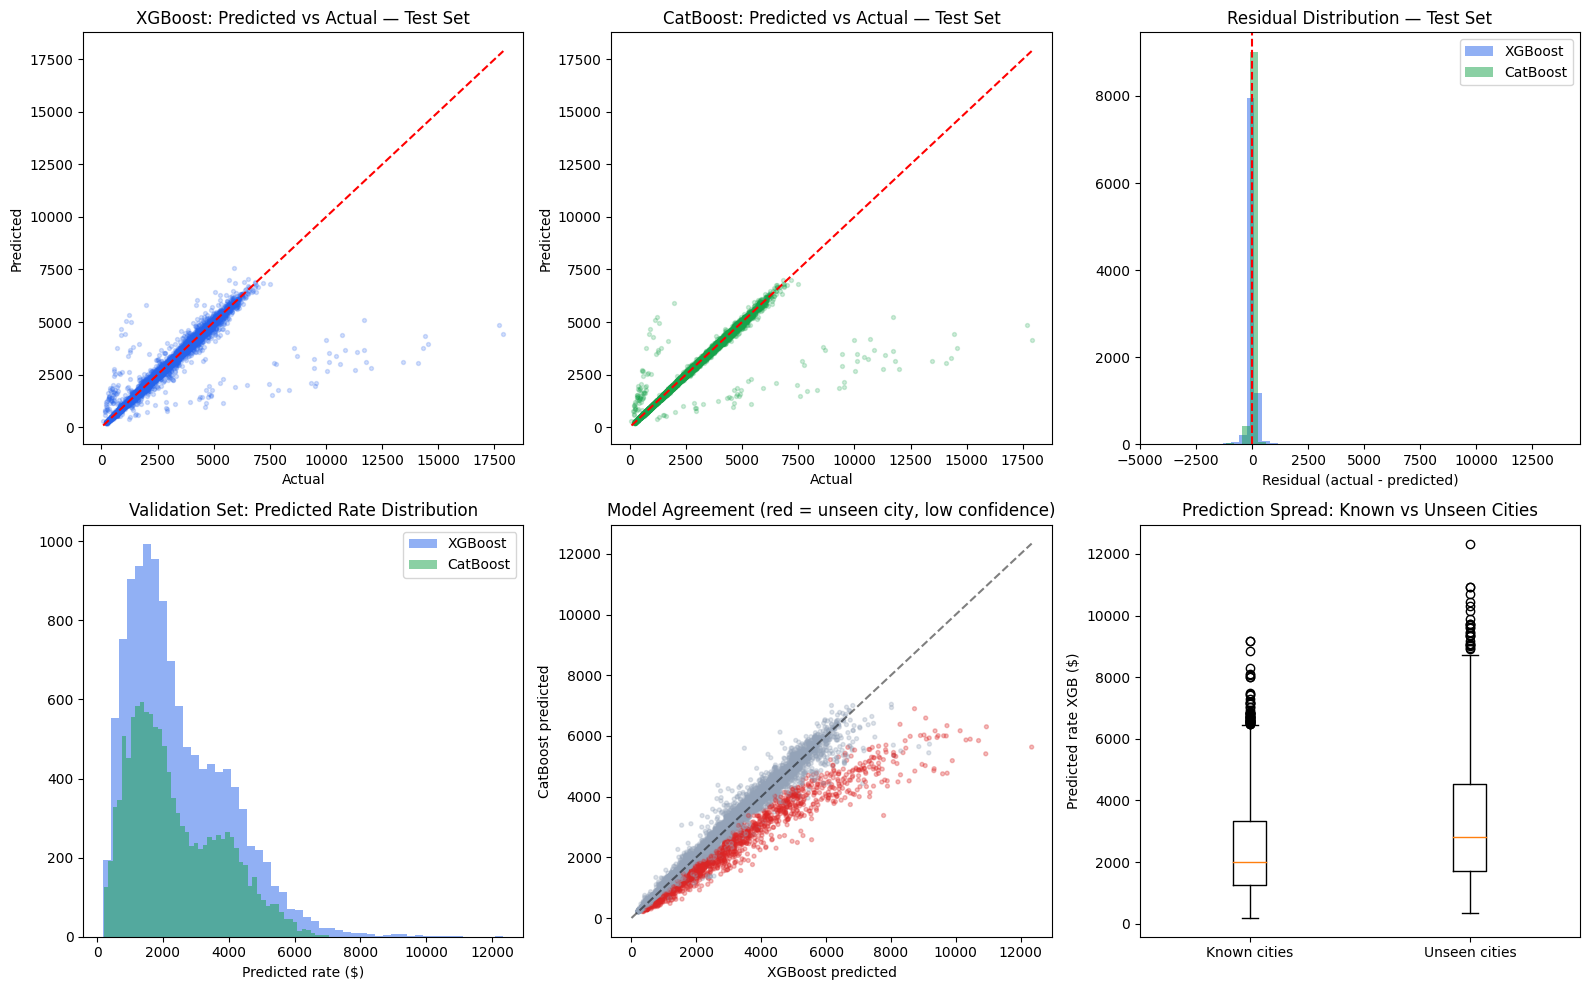

In [124]:

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))


axes[0,0].scatter(y_test, preds_xgb, alpha=0.2, s=8, color='#2563eb')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0,0].set_xlabel("Actual")
axes[0,0].set_ylabel("Predicted")
axes[0,0].set_title("XGBoost: Predicted vs Actual — Test Set")


axes[0,1].scatter(y_test, preds_cb, alpha=0.2, s=8, color='#16a34a')
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0,1].set_xlabel("Actual")
axes[0,1].set_ylabel("Predicted")
axes[0,1].set_title("CatBoost: Predicted vs Actual — Test Set")

res_xgb = y_test - preds_xgb
res_cb = y_test - preds_cb
axes[0,2].hist(res_xgb, bins=50, alpha=0.5, label='XGBoost', color='#2563eb')
axes[0,2].hist(res_cb, bins=50, alpha=0.5, label='CatBoost', color='#16a34a')
axes[0,2].axvline(0, color='r', linestyle='--')
axes[0,2].set_xlabel("Residual (actual - predicted)")
axes[0,2].set_title("Residual Distribution — Test Set")
axes[0,2].legend()

axes[1,0].hist(val_df['predicted_rate_xgb'], bins=50, alpha=0.5, label='XGBoost', color='#2563eb')
axes[1,0].hist(val_df['predicted_rate_cb'], bins=50, alpha=0.5, label='CatBoost', color='#16a34a')
axes[1,0].set_xlabel("Predicted rate ($)")
axes[1,0].set_title("Validation Set: Predicted Rate Distribution")
axes[1,0].legend()

axes[1,1].scatter(
    val_df['predicted_rate_xgb'], val_df['predicted_rate_cb'],
    c=val_df['low_confidence'].map({True:'#dc2626', False: '#94a3b8'}),
    alpha=0.3, s=8
)
lims = [0, max(val_df['predicted_rate_xgb'].max(), val_df['predicted_rate_cb'].max())]
axes[1,1].plot(lims, lims, 'k--', alpha=0.5)
axes[1,1].set_xlabel("XGBoost predicted")
axes[1,1].set_ylabel("CatBoost predicted")
axes[1,1].set_title("Model Agreement (red = unseen city, low confidence)")

data_box = [
    val_df[val_df['low_confidence'] == False]['predicted_rate_xgb'],
    val_df[val_df['low_confidence'] == True]['predicted_rate_xgb']
]

axes[1,2].boxplot(data_box, labels=['Known cities', 'Unseen cities'])
axes[1,2].set_ylabel("Predicted rate XGB ($)")
axes[1,2].set_title("Prediction Spread: Known vs Unseen Cities")

plt.tight_layout()
plt.savefig("evaluation_dashboard.png", dpi=110)
plt.show()

In [133]:
final_freight_rate = val_df[['load_id', 'predicted_rate_cb']].reset_index(drop=True)


In [134]:
final_freight_rate

,load_id,predicted_rate_cb
0,TE-000001,856.246980
1,TE-000002,5180.538194
2,TE-000003,5304.565052
3,TE-000004,4109.087207
4,TE-000005,1793.807468
...,...,...
11995,TE-011996,907.143571
11996,TE-011997,1538.235606
11997,TE-011998,915.374057
11998,TE-011999,3470.786298


In [138]:
final_freight_rate.to_csv('~/SpotterTask/data/validation_prediction.csv', index=False)